<a href="https://colab.research.google.com/github/Ajithredd123/Shopper-Spectrum/blob/main/Shopper_Spectrum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Project Name:Shopper Spectrum: Customer Segmentation and Product Recommendations in E-Commerce

#Project Summary


Shopper Spectrum is an end-to-end Data Science project built
on a real-world Online Retail dataset containing thousands of
transactions from customers across multiple countries.
The project is divided into two major components:

 🔹 COMPONENT 1 : CUSTOMER SEGMENTATION
Customers are segmented using RFM Analysis combined with
KMeans Clustering. Each customer is scored based on:

→ How RECENTLY they purchased       (Recency)

→ How OFTEN they purchase           (Frequency)

→ How MUCH money they have spent    (Monetary)

  Based on these scores, customers are grouped into 4
meaningful segments — High-Value, Regular, Occasional,
and At-Risk — enabling businesses to target the right
customers with the right strategy.

🔹 COMPONENT 2 : PRODUCT RECOMMENDATION
 A collaborative filtering based recommendation system is
built using Cosine Similarity on a Customer-Product matrix.
When a user inputs any product name, the system returns
the Top 5 most similar products purchased by similar
customers — enabling personalized shopping experiences.

 Both components are deployed together in an interactive
Streamlit Web Application with a clean UI for real-time
predictions and recommendations.



# KEY STEPS
1. Import Required Libraries
   - Pandas, NumPy
   - Matplotlib, Seaborn
   - Scikit-learn

2. Load the Dataset
   - Read the online retail dataset.
   - Explore rows, columns, and data types.

3. Data Preprocessing
   - Remove missing CustomerID values.
   - Remove duplicate records.
   - Exclude cancelled invoices (InvoiceNo starting with 'C').
   - Remove negative or zero Quantity and UnitPrice values.
   - Convert InvoiceDate to datetime format.

4. Exploratory Data Analysis (EDA)
   - Analyze sales by country.
   - Identify top-selling products.
   - Visualize monthly purchase trends.
   - Analyze customer spending patterns.
   - Plot RFM distributions.

5. Feature Engineering (RFM Analysis)
   - Recency: Days since last purchase.
   - Frequency: Number of purchases.
   - Monetary: Total amount spent.

6. Data Scaling
   - Standardize RFM values using StandardScaler.

7. Customer Segmentation
   - Apply K-Means clustering.
   - Use Elbow Method to determine optimal clusters.
   - Evaluate clusters using Silhouette Score.
   - Label customer segments.

8. Cluster Visualization
   - Create scatter plots and cluster visualizations.
   - Analyze customer behavior in each cluster.

9. Product Recommendation System
   - Create Customer-Product matrix.
   - Calculate cosine similarity.
   - Implement item-based collaborative filtering.
   - Recommend top 5 similar products.

10. Model Saving
    - Save clustering and recommendation models using Pickle.

11. Streamlit Application
    - Product recommendation module.
    - Customer segmentation prediction module.
    - Interactive user interface.

12. Conclusion
    - Summarize customer segments.
    - Present business insights and recommendations.


Github Link:

In [1]:
# Install required libraries
!pip install scikit-learn pandas numpy matplotlib seaborn openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Load the dataset (UCI Online Retail Dataset)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
df = pd.read_excel(url)

print("Shape:", df.shape)
print(df.head())
print(df.dtypes)
print(df.isnull().sum())

Shape: (541909, 8)
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice           

In [2]:
# 1. Remove rows with missing CustomerID
df = df.dropna(subset=['CustomerID'])

# 2. Exclude cancelled invoices (InvoiceNo starting with 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# 3. Remove negative or zero quantities and prices
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

# 4. Convert CustomerID to int
df['CustomerID'] = df['CustomerID'].astype(int)

# 5. Create TotalAmount column
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

# 6. Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("Cleaned Shape:", df.shape)
print(df.describe())

Cleaned Shape: (397884, 9)
            Quantity                    InvoiceDate      UnitPrice  \
count  397884.000000                         397884  397884.000000   
mean       12.988238  2011-07-10 23:41:23.511023360       3.116488   
min         1.000000            2010-12-01 08:26:00       0.001000   
25%         2.000000            2011-04-07 11:12:00       1.250000   
50%         6.000000            2011-07-31 14:39:00       1.950000   
75%        12.000000            2011-10-20 14:33:00       3.750000   
max     80995.000000            2011-12-09 12:50:00    8142.750000   
std       179.331775                            NaN      22.097877   

          CustomerID    TotalAmount  
count  397884.000000  397884.000000  
mean    15294.423453      22.397000  
min     12346.000000       0.001000  
25%     13969.000000       4.680000  
50%     15159.000000      11.800000  
75%     16795.000000      19.800000  
max     18287.000000  168469.600000  
std      1713.141560     309.071041  


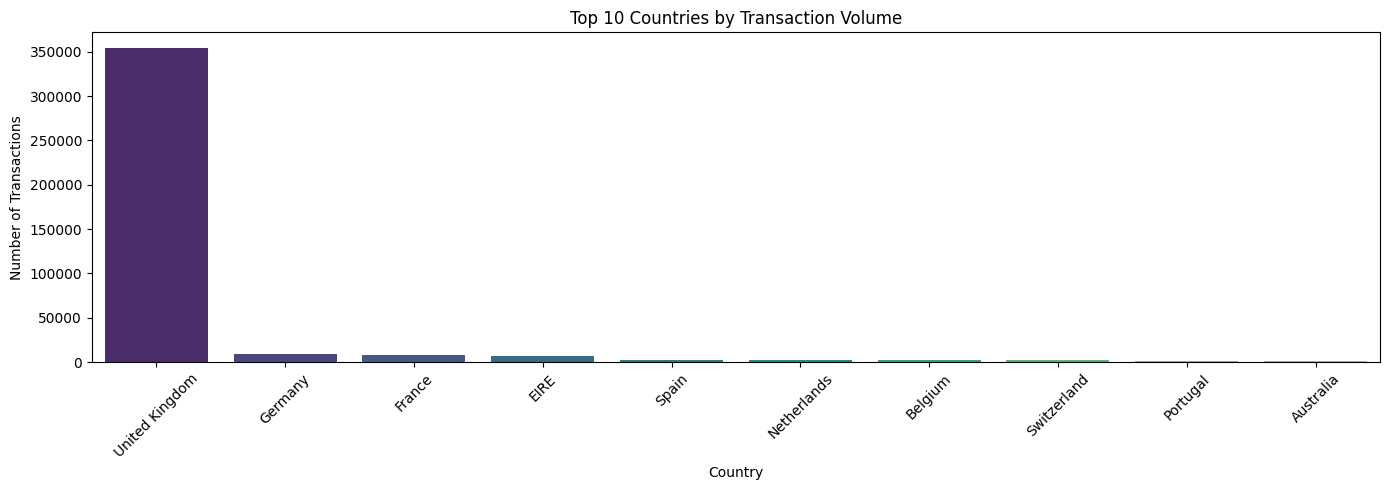

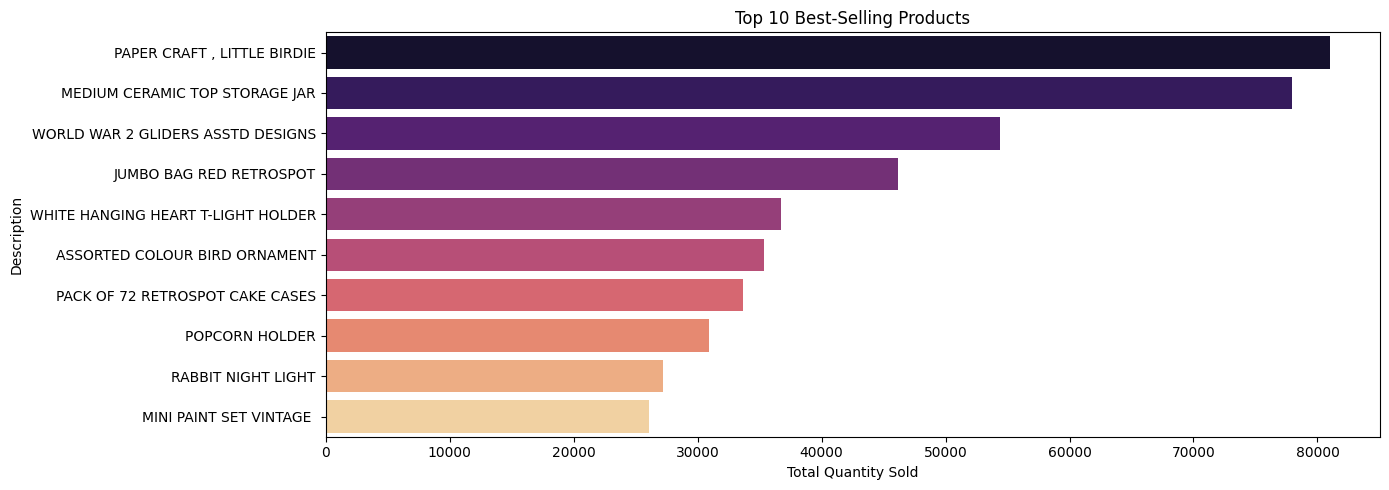

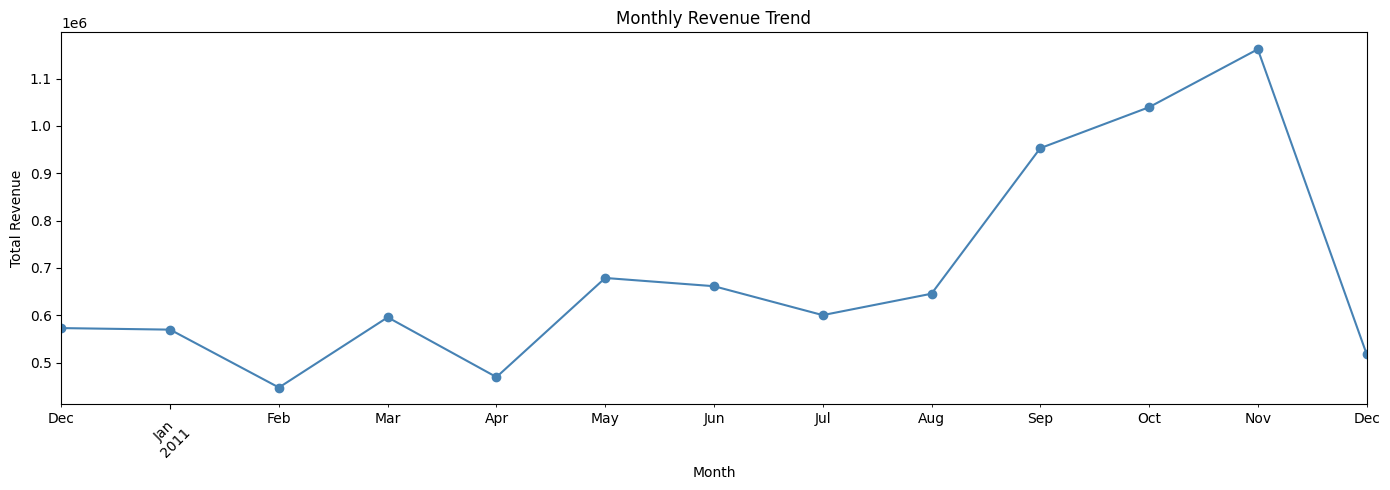

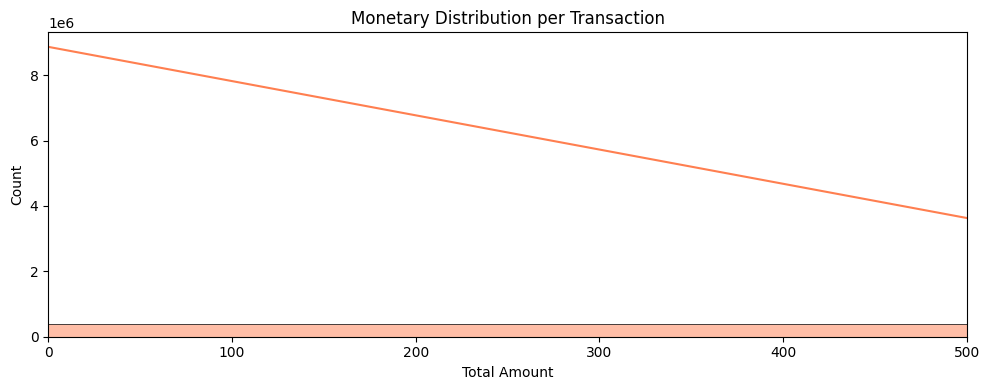

In [3]:
# --- 1. Transaction Volume by Country ---
plt.figure(figsize=(14, 5))
top_countries = df['Country'].value_counts().head(10)
sns.barplot(x=top_countries.index, y=top_countries.values, palette='viridis')
plt.title('Top 10 Countries by Transaction Volume')
plt.xticks(rotation=45)
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

# --- 2. Top Selling Products ---
plt.figure(figsize=(14, 5))
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_products.values, y=top_products.index, palette='magma')
plt.title('Top 10 Best-Selling Products')
plt.xlabel('Total Quantity Sold')
plt.tight_layout()
plt.show()

# --- 3. Purchase Trends Over Time ---
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
monthly_sales = df.groupby('YearMonth')['TotalAmount'].sum()

plt.figure(figsize=(14, 5))
monthly_sales.plot(kind='line', marker='o', color='steelblue')
plt.title('Monthly Revenue Trend')
plt.ylabel('Total Revenue')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- 4. Monetary Distribution per Transaction ---
plt.figure(figsize=(10, 4))
sns.histplot(df['TotalAmount'], bins=100, kde=True, color='coral')
plt.xlim(0, 500)
plt.title('Monetary Distribution per Transaction')
plt.xlabel('Total Amount')
plt.tight_layout()
plt.show()

   CustomerID  Recency  Frequency  Monetary
0       12346      326          1  77183.60
1       12347        2          7   4310.00
2       12348       75          4   1797.24
3       12349       19          1   1757.55
4       12350      310          1    334.40
         CustomerID      Recency    Frequency       Monetary
count   4338.000000  4338.000000  4338.000000    4338.000000
mean   15300.408022    92.536422     4.272015    2054.266460
std     1721.808492   100.014169     7.697998    8989.230441
min    12346.000000     1.000000     1.000000       3.750000
25%    13813.250000    18.000000     1.000000     307.415000
50%    15299.500000    51.000000     2.000000     674.485000
75%    16778.750000   142.000000     5.000000    1661.740000
max    18287.000000   374.000000   209.000000  280206.020000


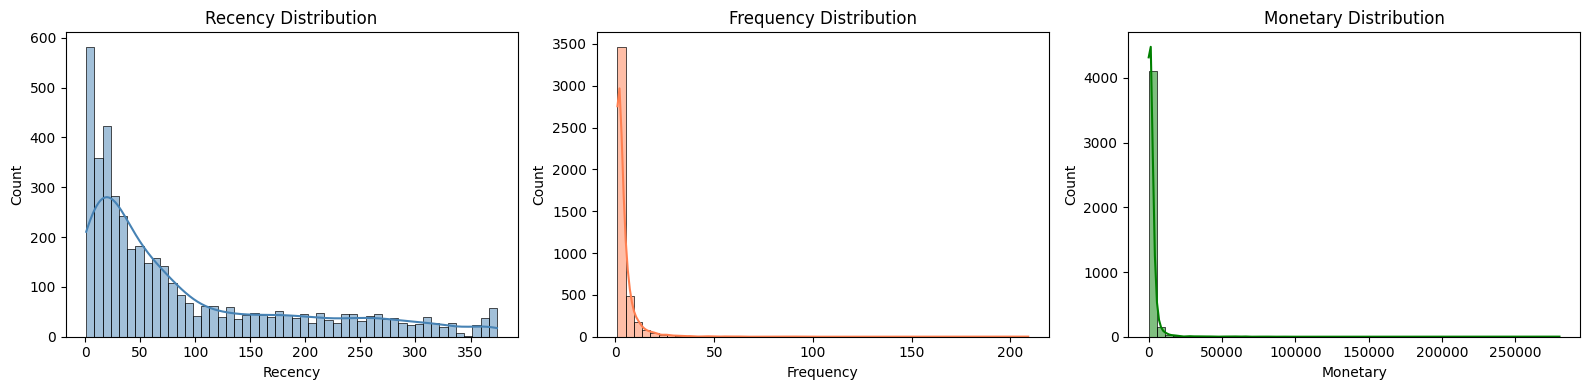

In [4]:
# Reference date = 1 day after the last transaction
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Calculate RFM
rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('InvoiceNo',   'nunique'),
    Monetary  = ('TotalAmount', 'sum')
).reset_index()

print(rfm.head())
print(rfm.describe())

# --- RFM Distributions ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, col in enumerate(['Recency', 'Frequency', 'Monetary']):
    sns.histplot(rfm[col], bins=50, ax=axes[i], kde=True, color=['steelblue','coral','green'][i])
    axes[i].set_title(f'{col} Distribution')
plt.tight_layout()
plt.show()

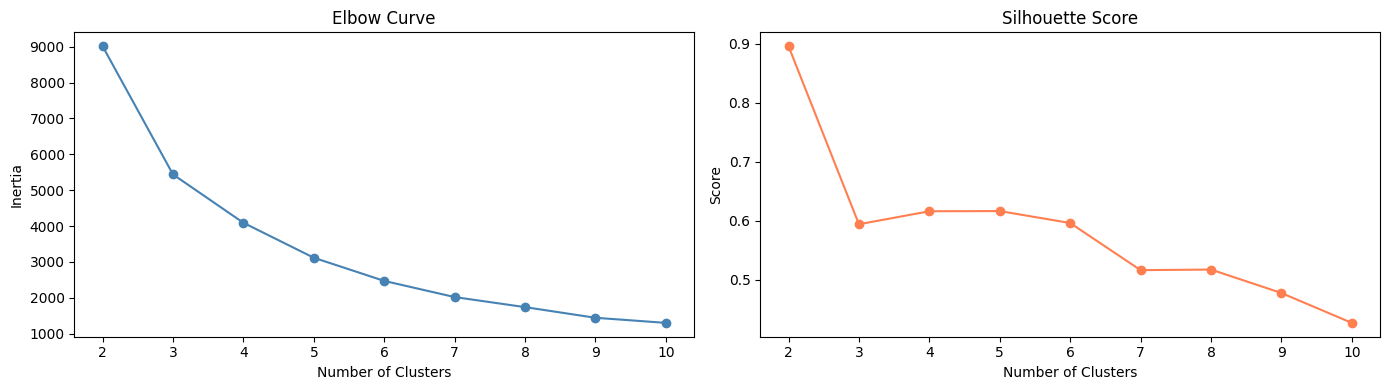

         Recency  Frequency  Monetary
Cluster                              
0           43.7        3.7    1359.0
1          248.1        1.6     480.6
2            7.4       82.5  127338.3
3           15.5       22.3   12709.1


In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Normalize RFM
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

# --- Elbow Method ---
inertia = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(rfm_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(K_range, inertia, marker='o', color='steelblue')
axes[0].set_title('Elbow Curve')
axes[0].set_xlabel('Number of Clusters')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, sil_scores, marker='o', color='coral')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters')
axes[1].set_ylabel('Score')
plt.tight_layout()
plt.show()

# --- Run KMeans with best K (e.g., 4) ---
best_k = 4
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
rfm['Cluster'] = km_final.fit_predict(rfm_scaled)

# --- Cluster Profiles ---
cluster_profile = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean().round(1)
print(cluster_profile)

Segment
Occasional    1757
Regular       1127
High-Value     744
At-Risk        710
Name: count, dtype: int64


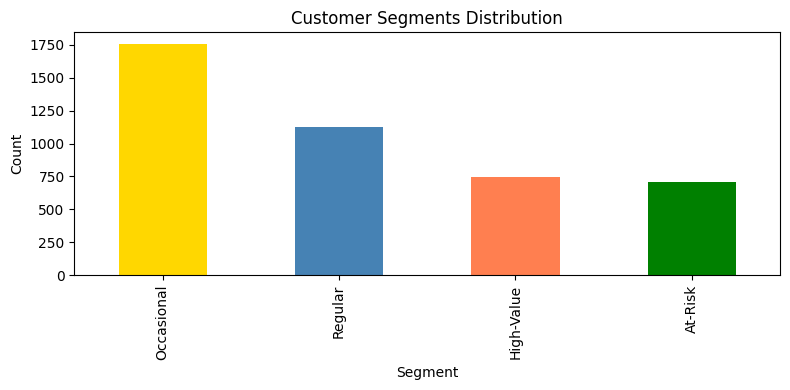

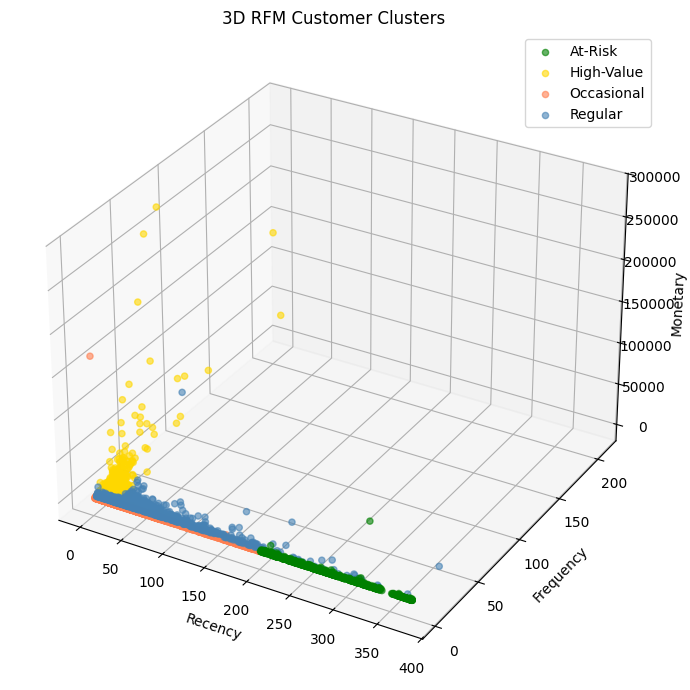

In [6]:
# Review cluster_profile output and assign labels accordingly
# Adjust the mapping below after checking your cluster_profile output

def label_cluster(row):
    r, f, m = row['Recency'], row['Frequency'], row['Monetary']
    if f >= 5 and m >= 1000 and r <= 30:
        return 'High-Value'
    elif f >= 3 and m >= 500:
        return 'Regular'
    elif r >= 200:
        return 'At-Risk'
    else:
        return 'Occasional'

rfm['Segment'] = rfm.apply(label_cluster, axis=1)
print(rfm['Segment'].value_counts())

# --- Cluster Bar Chart ---
rfm['Segment'].value_counts().plot(kind='bar', color=['gold','steelblue','coral','green'], figsize=(8,4))
plt.title('Customer Segments Distribution')
plt.xlabel('Segment')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# --- 3D Scatter Plot ---
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
colors = {'High-Value':'gold', 'Regular':'steelblue', 'Occasional':'coral', 'At-Risk':'green'}
for seg, grp in rfm.groupby('Segment'):
    ax.scatter(grp['Recency'], grp['Frequency'], grp['Monetary'],
               label=seg, alpha=0.6, color=colors[seg])
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')
ax.legend()
plt.title('3D RFM Customer Clusters')
plt.tight_layout()
plt.show()

['GIN + TONIC DIET METAL SIGN', 'RED HANGING HEART T-LIGHT HOLDER', 'WASHROOM METAL SIGN', 'LAUNDRY 15C METAL SIGN', 'GREEN VINTAGE SPOT BEAKER']


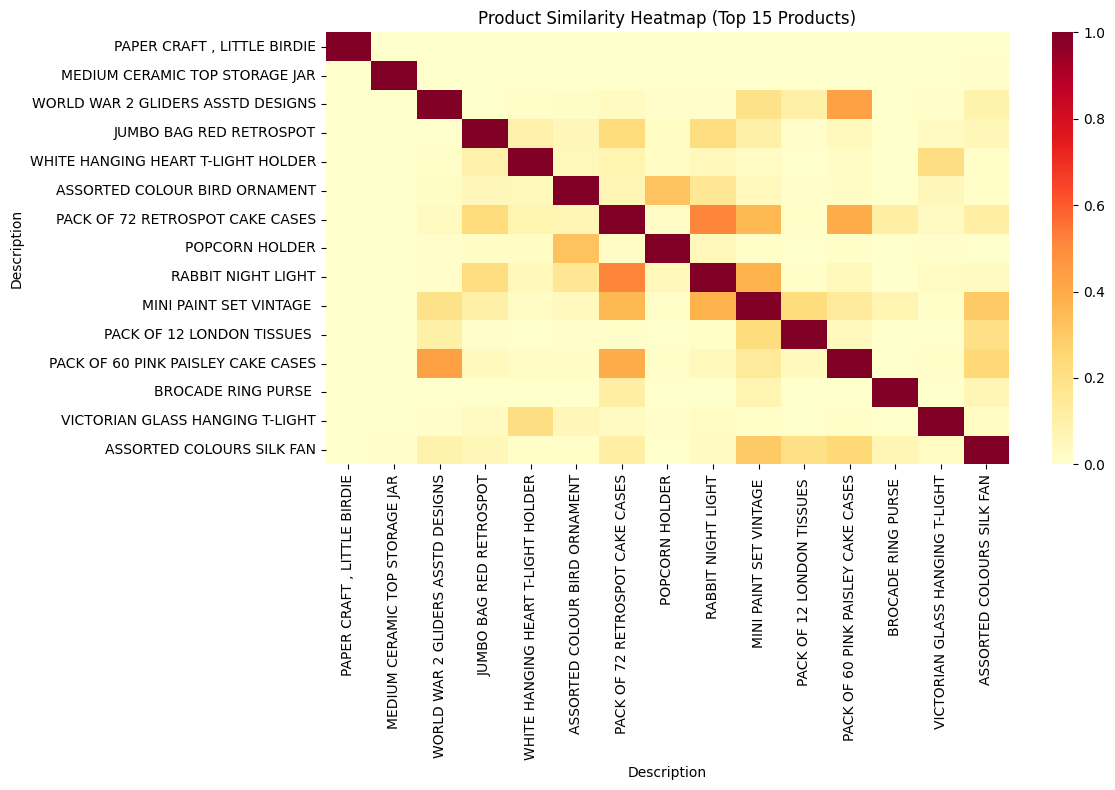

In [7]:
from sklearn.metrics.pairwise import cosine_similarity

# Build Customer-Product matrix
product_matrix = df.groupby(['CustomerID', 'Description'])['Quantity'].sum().unstack().fillna(0)

# Compute item-item cosine similarity
item_similarity = cosine_similarity(product_matrix.T)
item_sim_df = pd.DataFrame(item_similarity,
                            index=product_matrix.columns,
                            columns=product_matrix.columns)

# --- Recommendation Function ---
def get_recommendations(product_name, top_n=5):
    product_name = product_name.upper().strip()
    if product_name not in item_sim_df.index:
        return f"Product '{product_name}' not found in dataset."
    similar = item_sim_df[product_name].sort_values(ascending=False)[1:top_n+1]
    return list(similar.index)

# --- Test ---
print(get_recommendations("WHITE HANGING HEART T-LIGHT HOLDER"))

# --- Heatmap of top products similarity ---
top_items = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(15).index
sim_subset = item_sim_df.loc[top_items, top_items]

plt.figure(figsize=(12, 8))
sns.heatmap(sim_subset, cmap='YlOrRd', xticklabels=True, yticklabels=True)
plt.title('Product Similarity Heatmap (Top 15 Products)')
plt.tight_layout()
plt.show()

In [8]:
import pickle

# Save KMeans model
with open('kmeans_model.pkl', 'wb') as f:
    pickle.dump(km_final, f)

# Save Scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save item similarity dataframe
with open('item_sim_df.pkl', 'wb') as f:
    pickle.dump(item_sim_df, f)

# Save RFM with segments
rfm.to_csv('rfm_segments.csv', index=False)

print("✅ All models saved!")

# Download files from Colab
from google.colab import files
files.download('kmeans_model.pkl')
files.download('scaler.pkl')
files.download('item_sim_df.pkl')
files.download('rfm_segments.csv')

✅ All models saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
import streamlit as st
import pickle
import numpy as np
import pandas as pd

# Install Streamlit
!pip install streamlit

# Load models
with open('kmeans_model.pkl', 'rb') as f:
    model = pickle.load(f)
with open('scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)
with open('item_sim_df.pkl', 'rb') as f:
    item_sim_df = pickle.load(f)

# Segment label function (same logic as training)
def predict_segment(recency, frequency, monetary):
    scaled = scaler.transform([[recency, frequency, monetary]])
    cluster = model.predict(scaled)[0]
    # Map cluster number to label using same logic
    if frequency >= 5 and monetary >= 1000 and recency <= 30:
        return 'High-Value 🏆'
    elif frequency >= 3 and monetary >= 500:
        return 'Regular 🛍️'
    elif recency >= 200:
        return 'At-Risk ⚠️'
    else:
        return 'Occasional 🛒'

def get_recommendations(product_name, top_n=5):
    product_name = product_name.upper().strip()
    if product_name not in item_sim_df.index:
        return None
    return list(item_sim_df[product_name].sort_values(ascending=False)[1:top_n+1].index)

# --- Streamlit UI ---
st.set_page_config(page_title="Shopper Spectrum", layout="wide")
st.sidebar.title("Navigation")
page = st.sidebar.radio("Go to", ["Home", "Clustering", "Recommendation"])

if page == "Home":
    st.title("🛒 Shopper Spectrum")
    st.markdown("Customer Segmentation & Product Recommendation System")

elif page == "Recommendation":
    st.title("🎯 Product Recommender")
    product = st.text_input("Enter Product Name (e.g. GREEN VINTAGE SPOT BEAKER)")
    if st.button("Get Recommendations"):
        results = get_recommendations(product)
        if results:
            st.success("Recommended Products:")
            for r in results:
                st.markdown(f"- **{r}**")
        else:
            st.error("Product not found. Try another name.")

elif page == "Clustering":
    st.title("📊 Customer Segmentation")
    recency   = st.number_input("Recency (days since last purchase)", min_value=0, value=30)
    frequency = st.number_input("Frequency (number of purchases)",    min_value=1, value=5)
    monetary  = st.number_input("Monetary (total spend)",             min_value=0.0, value=500.0)
    if st.button("Predict Segment"):
        segment = predict_segment(recency, frequency, monetary)
        st.markdown(f"### This customer belongs to: **{segment}**")

ModuleNotFoundError: No module named 'streamlit'

In [ ]:
!pip install streamlit pyngrok -q


In [ ]:
%%writefile app.py
import streamlit as st
import pickle
import numpy as np
import pandas as pd

# Load models
with open('kmeans_model.pkl', 'rb') as f:
    model = pickle.load(f)
with open('scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)
with open('item_sim_df.pkl', 'rb') as f:
    item_sim_df = pickle.load(f)

def predict_segment(recency, frequency, monetary):
    scaled = scaler.transform([[recency, frequency, monetary]])
    cluster = model.predict(scaled)[0]
    if frequency >= 5 and monetary >= 1000 and recency <= 30:
        return 'High-Value 🏆'
    elif frequency >= 3 and monetary >= 500:
        return 'Regular 🛍️'
    elif recency >= 200:
        return 'At-Risk ⚠️'
    else:
        return 'Occasional 🛒'

def get_recommendations(product_name, top_n=5):
    product_name = product_name.upper().strip()
    if product_name not in item_sim_df.index:
        # Find close matches
        suggestions = [p for p in item_sim_df.index if product_name in p]
        return None, suggestions[:5]
    similar = item_sim_df[product_name].sort_values(ascending=False)[1:top_n+1]
    return list(similar.index), []

st.set_page_config(page_title="Shopper Spectrum", layout="wide")
st.sidebar.title("Navigation")
page = st.sidebar.radio("Go to", ["Home", "Clustering", "Recommendation"])

if page == "Home":
    st.title("🛒 Shopper Spectrum")
    st.markdown("### Customer Segmentation & Product Recommendation System")
    st.info("Use the sidebar to navigate between modules.")

elif page == "Recommendation":
    st.title("🎯 Product Recommender")

    # Show searchable dropdown of all products
    all_products = sorted(item_sim_df.index.tolist())
    selected = st.selectbox("Select a Product (or type to search):", all_products)

    # Also allow manual text input
    product = st.text_input("Or type Product Name manually:", value=selected)

    if st.button("Get Recommendations"):
        results, suggestions = get_recommendations(product)
        if results:
            st.success("✅ Recommended Products:")
            for i, r in enumerate(results, 1):
                st.markdown(f"**{i}.** {r}")
        elif suggestions:
            st.warning("Product not found exactly. Did you mean:")
            for s in suggestions:
                st.markdown(f"- {s}")
        else:
            st.error("No match found at all. Please try a different name.")

elif page == "Clustering":
    st.title("📊 Customer Segmentation")
    recency   = st.number_input("Recency (days since last purchase)", min_value=0, value=30)
    frequency = st.number_input("Frequency (number of purchases)", min_value=1, value=5)
    monetary  = st.number_input("Monetary (total spend)", min_value=0.0, value=500.0)
    if st.button("Predict Segment"):
        segment = predict_segment(recency, frequency, monetary)
        st.markdown(f"### This customer belongs to: **{segment}**")

In [ ]:
# 1. Go to https://ngrok.com → Sign up free → Copy your auth token
# 2. Paste it below and run

from pyngrok import ngrok
import subprocess, time

# Set your ngrok auth token here
ngrok.set_auth_token("3FcNLT4F6k5XE1LB9PS9qFHyDZt_96QpduWLir17bbQaMSxG")

# Kill any existing streamlit processes
subprocess.run(["pkill", "-f", "streamlit"], capture_output=True)
time.sleep(1)

# Start streamlit in background
process = subprocess.Popen(
    ["streamlit", "run", "app.py", "--server.port=8501", "--server.headless=true"],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)
time.sleep(4)

# Create public URL
public_url = ngrok.connect(8501)
print("=" * 50)
print(f"✅ App is LIVE at: {public_url}")
print("=" * 50)
print("Click the link above to open your Streamlit app!")

In [ ]:
# See all available product names
print(item_sim_df.index.tolist()[:50])  # prints first 50 products

In [ ]:
# Search for products containing a keyword
keyword = "GREEN"
matches = [p for p in item_sim_df.index if keyword in p]
print(matches[:20])